<a href="https://colab.research.google.com/github/Ali13fffff/bank-customer-churn-analysis/blob/main/Copy_of_Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data

In [4]:
df=pd.read_csv("Churn_Modelling.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

#Cleaning Data

In [5]:
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
df.drop_duplicates(inplace=True)
print(df.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


#Overall Data Analysis

In [6]:

churn_percent = df["Exited"].value_counts(normalize=True) * 100
print(churn_percent)
balance_mean = df.groupby("Exited")["Balance"].mean()
print(balance_mean)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64
Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64


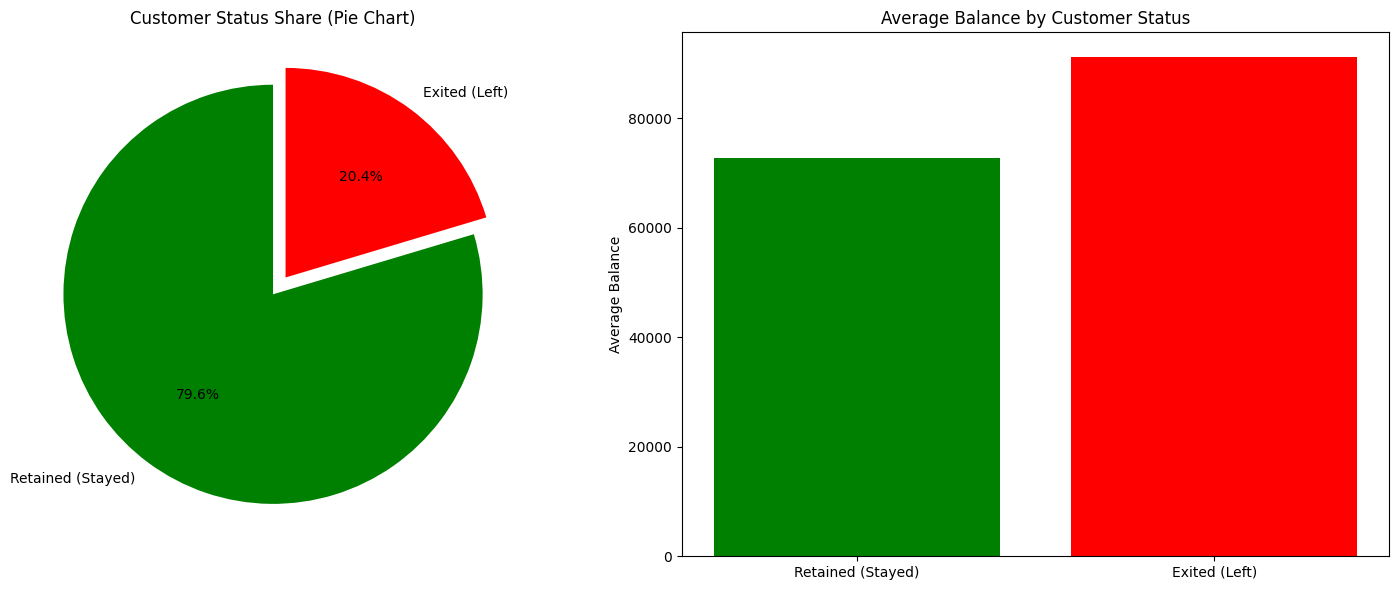

In [7]:



exited_counts = df["Exited"].value_counts().sort_index()
balance_mean = df.groupby("Exited")["Balance"].mean().sort_index()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.pie(
    exited_counts,
    labels=["Retained (Stayed)", "Exited (Left)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["Green", "Red"],
    explode=(0, 0.1)
)
plt.title("Customer Status Share (Pie Chart)")

plt.subplot(1, 2, 2)
plt.bar(
    ["Retained (Stayed)", "Exited (Left)"],
    balance_mean.values,
    color=["Green", "Red"]
)
plt.title("Average Balance by Customer Status")
plt.ylabel("Average Balance")
plt.tight_layout()
plt.show()

#Around 79.6% of customers stayed with the bank, while 20.4% churned. Although the churn rate does not seem alarming at first, churned customers had a higher average balance than retained customers. This suggests the bank may be losing more valuable customers, making churn a more important business issue than the percentage alone indicates.

#Category_col Analysis

In [8]:



# --------------------------
# Geography summary
# --------------------------
geography_summary = df.groupby("Geography").agg(
    customer_count=("Exited", "count"),
    churn_count=("Exited", "sum"),
    churn_rate=("Exited", "mean"),
    average_balance=("Balance", "mean"),
    lost_balance=("Balance", lambda balance: balance[df.loc[balance.index, "Exited"] == 1].sum())
).reset_index()


geography_summary["churn_rate"] = geography_summary["churn_rate"] * 100


geography_summary = geography_summary.sort_values(by="churn_rate", ascending=False)

print("========== Geography Summary ==========")
print(geography_summary)
print()


# -------------------------------
# Gender summary
# -------------------------------
gender_summary = df.groupby("Gender").agg(
    customer_count=("Exited", "count"),
    churn_count=("Exited", "sum"),
    churn_rate=("Exited", "mean"),
    average_balance=("Balance", "mean"),
    lost_balance=("Balance", lambda balance: balance[df.loc[balance.index, "Exited"] == 1].sum())
).reset_index()


gender_summary["churn_rate"] = gender_summary["churn_rate"] * 100


gender_summary = gender_summary.sort_values(by="churn_rate", ascending=False)

print("========== Gender Summary ==========")
print(gender_summary)
print()

========== Geography Summary ==========
  Geography  customer_count  churn_count  churn_rate  average_balance  \
1   Germany            2509          814   32.443204    119730.116134   
2     Spain            2477          413   16.673395     61818.147763   
0    France            5014          810   16.154767     62092.636516   

   lost_balance  
1   97973915.53  
2   29948014.56  
0   57666164.54  

========== Gender Summary ==========
   Gender  customer_count  churn_count  churn_rate  average_balance  \
0  Female            4543         1139   25.071539     75659.369139   
1    Male            5457          898   16.455928     77173.974506   

   lost_balance  
0  1.014127e+08  
1  8.417536e+07  



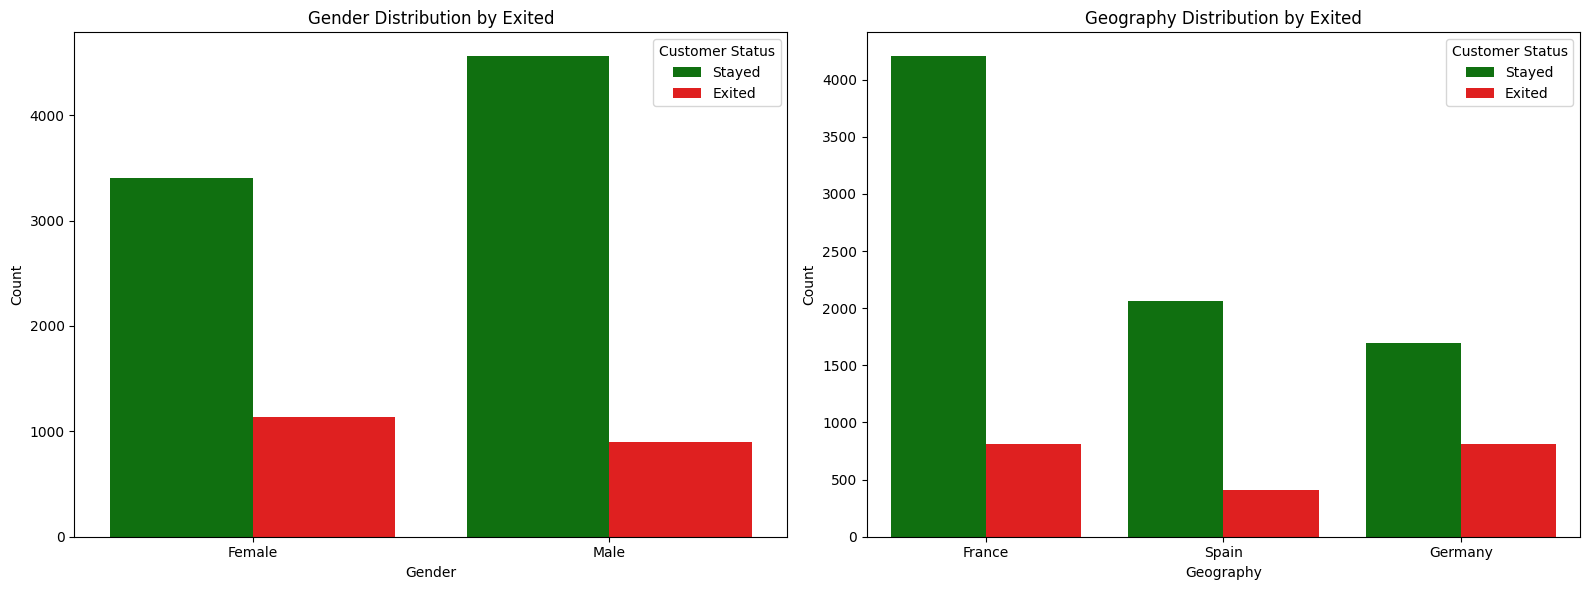

In [9]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x="Gender", hue="Exited", palette=["green", "red"], ax=axes[0])
sns.countplot(data=df, x="Geography", hue="Exited", palette=["green", "red"], ax=axes[1])

axes[0].set_title("Gender Distribution by Exited")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

axes[1].set_title("Geography Distribution by Exited")
axes[1].set_xlabel("Geography")
axes[1].set_ylabel("Count")

axes[0].legend(["Stayed", "Exited"], title="Customer Status")
axes[1].legend(["Stayed", "Exited"], title="Customer Status")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1770/1792363456.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_summary, x="Gender", y="churn_rate", palette="Set2", ax=axes[0, 0])
/tmp/ipykernel_1770/1792363456.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_summary, x="Gender", y="lost_balance", palette="Reds", ax=axes[0, 1])
/tmp/ipykernel_1770/1792363456.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_summary, x="Geography", y="churn_rate", palette="Set3", ax=axes[1, 0])
/tmp/ipykernel_1770/1792363456.py:39: FutureWarning: 

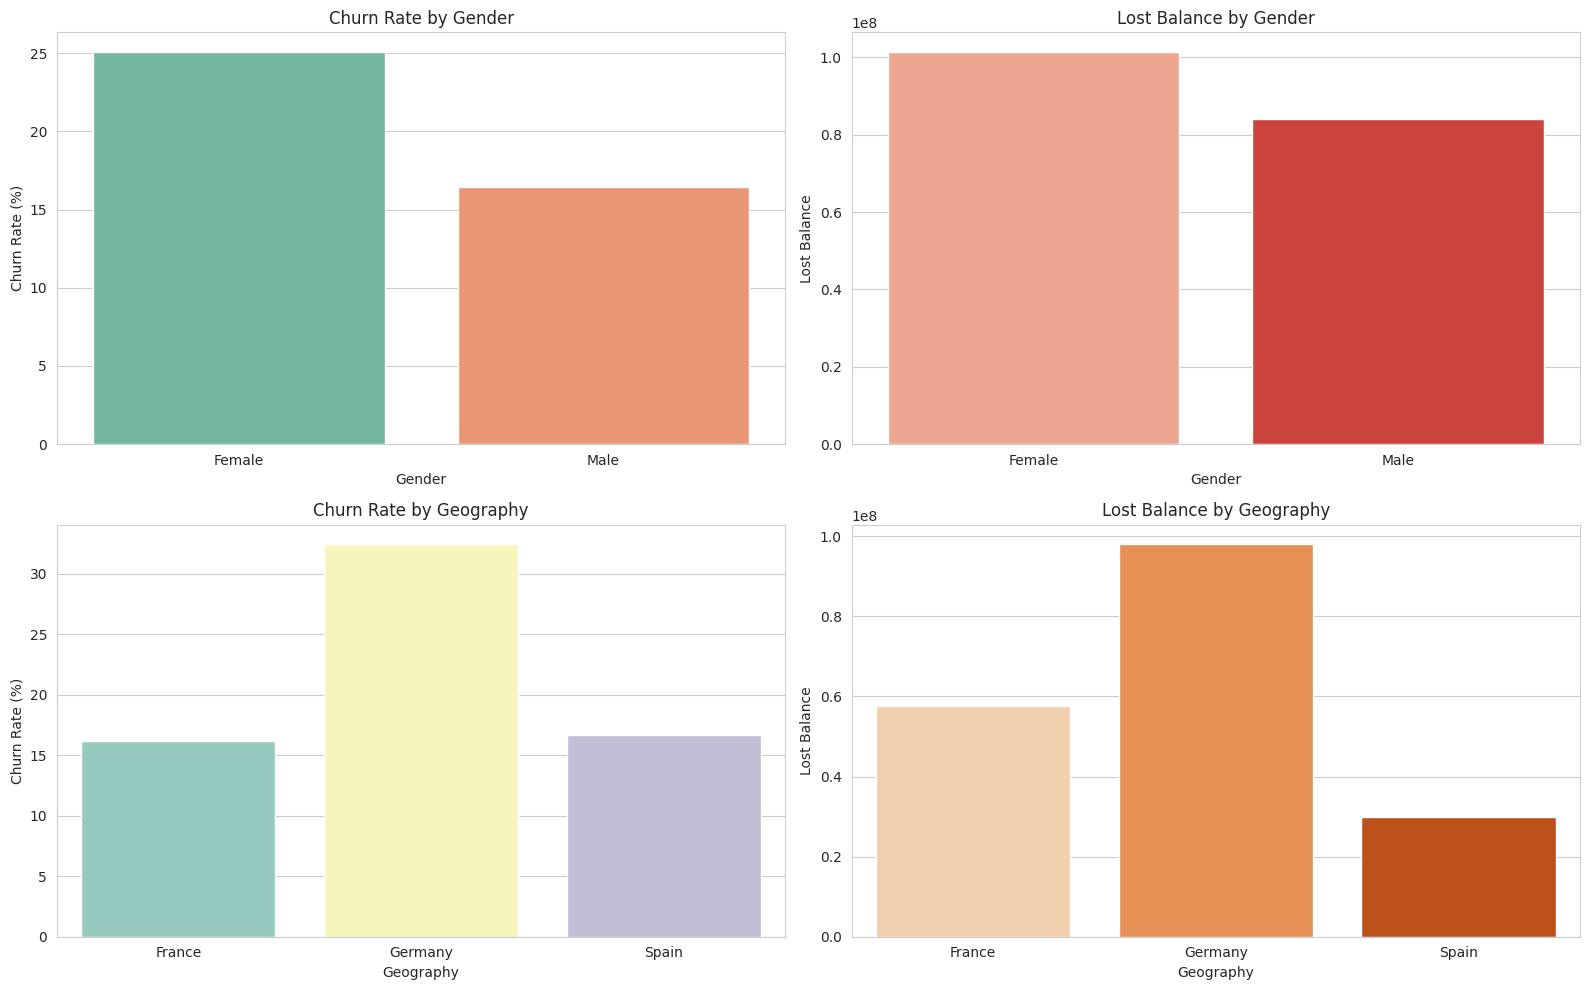

In [10]:



gender_summary = df.groupby("Gender").agg(
    churn_rate=("Exited", "mean"),
    lost_balance=("Balance", lambda x: x[df.loc[x.index, "Exited"] == 1].sum())
).reset_index()


geo_summary = df.groupby("Geography").agg(
    churn_rate=("Exited", "mean"),
    lost_balance=("Balance", lambda x: x[df.loc[x.index, "Exited"] == 1].sum())
).reset_index()


gender_summary["churn_rate"] = gender_summary["churn_rate"] * 100
geo_summary["churn_rate"] = geo_summary["churn_rate"] * 100


sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. churn rate by Gender
sns.barplot(data=gender_summary, x="Gender", y="churn_rate", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Churn Rate by Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Churn Rate (%)")


sns.barplot(data=gender_summary, x="Gender", y="lost_balance", palette="Reds", ax=axes[0, 1])
axes[0, 1].set_title("Lost Balance by Gender")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Lost Balance")


sns.barplot(data=geo_summary, x="Geography", y="churn_rate", palette="Set3", ax=axes[1, 0])
axes[1, 0].set_title("Churn Rate by Geography")
axes[1, 0].set_xlabel("Geography")
axes[1, 0].set_ylabel("Churn Rate (%)")


sns.barplot(data=geo_summary, x="Geography", y="lost_balance", palette="Oranges", ax=axes[1, 1])
axes[1, 1].set_title("Lost Balance by Geography")
axes[1, 1].set_xlabel("Geography")
axes[1, 1].set_ylabel("Lost Balance")

plt.tight_layout()
plt.show()

#Key Insights from Exploratory Data Analysis
Our initial deep dive into customer demographics reveals two critical business insights that challenge a simple view of the overall 20.4% churn rate:

1. Gender Disparity in Churn Risk
While the dataset shows a higher volume of male customers, the churn rate for female customers is significantly higher (approx. 25%) compared to their male counterparts (approx. 16%). This suggests that retention strategies are failing the female customer segment, and the bank is losing female customers at a disproportionately high rate. Furthermore, the analysis indicates a higher total lost balance attributed to the departure of female customers, suggesting that this segment holds a higher financial value at risk.
2. Geographical Risk and High-Value Loss
Customer distribution is highest in France, confirming successful acquisition efforts in the home country. However, the churn analysis by geography highlights a major risk in the German market. German customers show the highest churn rate (approx. 32.4%), nearly double the rate of both French and Spanish segments (approx. 16%). Most critically, the German segment also accounts for the highest total lost balance among all geographies.

Business Implication:

These findings mandate immediate, targeted interventions:

A dedicated strategy is needed to
address the factors driving the high churn rate among female customers.
The bank must prioritize retention efforts in Germany, as this region represents the highest risk in terms of both customer volume loss and financial value leakage.